# Notebook 03 — Expanding-Window Backtest (Protocol B)

Instead of one cutoff, we evaluate at multiple cutoffs and measure *variance* across windows. A model that is consistently mediocre beats one that is brilliant on lucky cutoffs and terrible on unlucky ones.

In [1]:
import json
import logging
import warnings
from pathlib import Path

logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100})

FIGURES_DIR = Path("outputs/figures")
RESULTS_DIR = Path("outputs/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=120)
    print(f"Saved figure → {path}")


def save_json(data, name: str) -> None:
    path = RESULTS_DIR / name
    if isinstance(data, pd.DataFrame):
        payload = data.to_dict(orient="records")
    else:
        payload = data
    path.write_text(json.dumps(payload, indent=2, default=str))
    print(f"Saved results → {path}")


print("Ready.")


Ready.


In [2]:
from src.datasets.loader import load_airline, load_electricity, load_retail_base
from src.datasets.injector import inject_anomalies, ANOMALY_EVENTS

airline     = load_airline()
electricity = load_electricity()
retail_base = load_retail_base()
retail      = inject_anomalies(retail_base)

for name, s in [("Airline", airline), ("Electricity", electricity), ("Retail", retail)]:
    print(f"{name:15s}  {len(s):4d} pts  "
          f"{s.index[0].date()} → {s.index[-1].date()}  mean={s.mean():.1f}")


Airline           144 pts  1949-01-01 → 1960-12-01  mean=280.3
Electricity       397 pts  1990-01-01 → 2023-01-01  mean=132.1
Retail            208 pts  2020-01-06 → 2023-12-25  mean=545.6


In [3]:
from src.models.naive import SeasonalNaive
from src.models.arima import ARIMAModel
from src.models.prophet_model import ProphetModel
from src.models.xgboost_model import XGBoostModel
from src.models.lstm_model import LSTMModel

# LSTM uses reduced config for notebook speed; set INCLUDE_LSTM=True to enable
INCLUDE_LSTM = False


def make_factories(period: int = 12) -> dict:
    # Period-aware lag sets: monthly captures 2-year cycle; weekly captures annual (52w)
    if period == 52:
        lags = [1, 2, 3, 4, 13, 26]   # no lag-52: needs 52+ train pts, starves early cutoffs
        rolling = [4, 13, 26]
        arima_seasonal = (0, 0, 0, 0)  # seasonal ARIMA with period=52 is prohibitively slow
    else:
        lags = [1, 2, 3, 6, 12, 24]
        rolling = [3, 6, 12]
        arima_seasonal = (1, 1, 1, period)

    factories = {
        "Naive":   lambda: SeasonalNaive(period=period),
        "ARIMA":   lambda: ARIMAModel(order=(1, 1, 1), seasonal_order=arima_seasonal),
        "Prophet": ProphetModel,
        "XGBoost": lambda: XGBoostModel(n_estimators=100, max_depth=3,
                                         learning_rate=0.05, subsample=0.8,
                                         lags=lags, rolling_windows=rolling),
    }
    if INCLUDE_LSTM:
        factories["LSTM"] = lambda: LSTMModel(hidden_size=16, num_layers=2, epochs=20,
                                               seq_len=period)
    return factories


DATASETS = {
    "Airline":     (airline,     12),
    "Electricity": (electricity, 12),
    "Retail":      (retail,      52),
}


Importing plotly failed. Interactive plots will not work.


## Protocol B: expanding-window backtest

At each cutoff we train on all data up to that point and forecast one step ahead. We use `n_cutoffs=6` here for notebook speed; the full run uses 12.

In [4]:
from src.evaluation.backtest import expanding_window_backtest

N_CUTOFFS = 6  # increase for more thorough evaluation

# Run on Airline first as a walkthrough
airline_results = {}
for model_name, factory in make_factories(12).items():
    df = expanding_window_backtest(airline, factory, n_cutoffs=N_CUTOFFS,
                                   min_train_size=36)
    airline_results[model_name] = df
    print(f"  {model_name:10s}  mean RMSE={df['rmse'].mean():.2f}  "
          f"std={df['rmse'].std():.2f}")

airline_summary = pd.concat(
    {m: df.assign(model=m) for m, df in airline_results.items()}
).reset_index(drop=True)
save_json(airline_summary, "03_backtest_airline_cutoffs.json")


  Naive       mean RMSE=30.00  std=15.19


/workspaces/timeseries_evaluation_arena/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


13:27:42 - cmdstanpy - INFO - Chain [1] start processing


  ARIMA       mean RMSE=8.35  std=5.68


13:27:42 - cmdstanpy - INFO - Chain [1] done processing


...

13:27:43 - cmdstanpy - INFO - Chain [1] start processing


13:27:43 - cmdstanpy - INFO - Chain [1] done processing


13:27:43 - cmdstanpy - INFO - Chain [1] start processing


13:27:43 - cmdstanpy - INFO - Chain [1] done processing


  Prophet     mean RMSE=24.33  std=17.95
  XGBoost     mean RMSE=15.42  std=15.57
Saved results → outputs/results/03_backtest_airline_cutoffs.json


## RMSE by cutoff — Airline Passengers

Saved figure → outputs/figures/03_backtest_airline.png


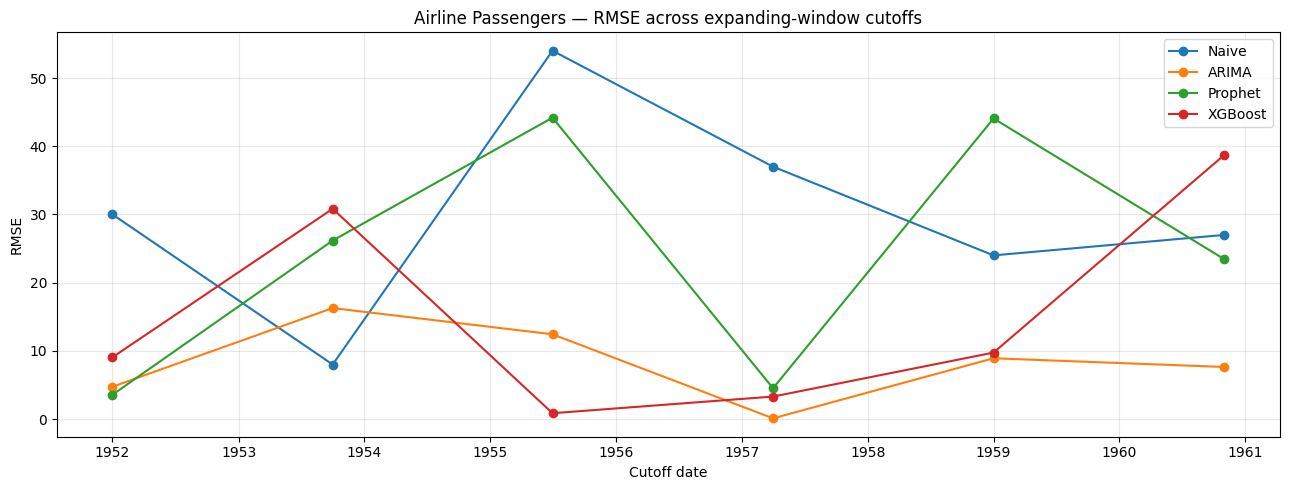

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
for model_name, df in airline_results.items():
    ax.plot(df["cutoff"], df["rmse"], marker="o", label=model_name)
ax.set_title("Airline Passengers — RMSE across expanding-window cutoffs")
ax.set_xlabel("Cutoff date")
ax.set_ylabel("RMSE")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "03_backtest_airline.png")
plt.show()


## Run Protocol B on all three datasets

In [6]:
all_backtest = {}  # {(dataset, model): DataFrame}

for ds_name, (series, period) in DATASETS.items():
    min_train = 36 if period == 12 else 60
    for model_name, factory in make_factories(period).items():
        df = expanding_window_backtest(series, factory, n_cutoffs=N_CUTOFFS,
                                       min_train_size=min_train)
        all_backtest[(ds_name, model_name)] = df
    print(f"Done: {ds_name}")


/workspaces/timeseries_evaluation_arena/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


13:27:45 - cmdstanpy - INFO - Chain [1] start processing


13:27:45 - cmdstanpy - INFO - Chain [1] done processing


13:27:45 - cmdstanpy - INFO - Chain [1] start processing


13:27:46 - cmdstanpy - INFO - Chain [1] done processing


...

13:27:52 - cmdstanpy - INFO - Chain [1] start processing


13:27:53 - cmdstanpy - INFO - Chain [1] done processing


13:27:53 - cmdstanpy - INFO - Chain [1] start processing


13:27:53 - cmdstanpy - INFO - Chain [1] done processing


Done: Retail


## Mean RMSE ± std across cutoffs

In [7]:
summary_rows = []
for (ds_name, model_name), df in all_backtest.items():
    summary_rows.append({
        "Dataset": ds_name,
        "Model":   model_name,
        "Mean RMSE": df["rmse"].mean(),
        "Std RMSE":  df["rmse"].std(),
        "CV (%)":    df["rmse"].std() / df["rmse"].mean() * 100,
    })

summary = pd.DataFrame(summary_rows).round(3)
save_json(summary, "03_backtest_summary.json")
summary.pivot_table(index="Model", columns="Dataset", values="Mean RMSE").round(2)


Saved results → outputs/results/03_backtest_summary.json


Dataset,Airline,Electricity,Retail
Model,,,
ARIMA,8.35,5.08,16.49
Naive,30.00,6.19,34.58
Prophet,24.33,4.31,21.00
XGBoost,15.42,19.81,16.47


### Variance (std) — who is most stable?

In [8]:
summary.pivot_table(index="Model", columns="Dataset", values="Std RMSE").round(3)


Dataset,Airline,Electricity,Retail
Model,,,
ARIMA,5.678,1.671,6.669
Naive,15.192,3.960,20.240
Prophet,17.949,2.209,15.596
XGBoost,15.569,2.478,3.564


## RMSE box plot across cutoffs — Retail

Saved figure → outputs/figures/03_boxplot_retail.png


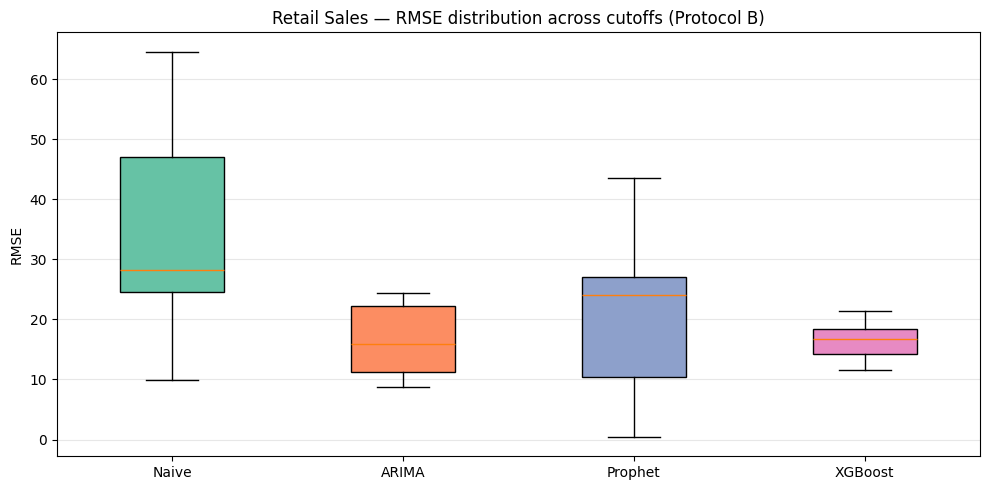

In [9]:
retail_dfs = {m: df for (ds, m), df in all_backtest.items() if ds == "Retail"}

fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot = [df["rmse"].values for df in retail_dfs.values()]
bp = ax.boxplot(data_to_plot, labels=list(retail_dfs.keys()), patch_artist=True)
colors = plt.cm.Set2.colors
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title("Retail Sales — RMSE distribution across cutoffs (Protocol B)")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
save_fig(fig, "03_boxplot_retail.png")
plt.show()


## Conclusion

The expanding-window backtest reveals *variance* — a metric invisible to the single-cutoff approach. Some models look great on average but are highly variable across cutoffs (risky in production). Others are consistently mediocre (predictable and manageable).

Next: we'll see that RMSE itself can be the wrong metric when errors have asymmetric business costs.